In [1]:
import qcodes as qc
import matplotlib.pyplot as plt
import numpy as np

In [2]:
db_path = r"C:\Users\emile\Thesis\Data_processing\Marcus_old_sample\Marcus_old_sample.db"

qc.initialise_or_create_database_at(db_path)

experiment = qc.load_or_create_experiment(experiment_name="IV_curves", sample_name="Marcus_old_sample")

In [3]:
experiment

IV_curves#Marcus_old_sample#3@C:\Users\emile\Thesis\Data_processing\Marcus_old_sample\Marcus_old_sample.db
----------------------------------------------------------------------------------------------------------
6-Column_4-1-voltage_source_ch1_source_voltage,voltage_source_ch1_current-51
7-Column_4-2-voltage_source_ch1_source_voltage,voltage_source_ch1_current-51
8-Column_4-3-voltage_source_ch1_source_voltage,voltage_source_ch1_current-51
9-Column_4-4-voltage_source_ch1_source_voltage,voltage_source_ch1_current-101

In [4]:
dataset = qc.load_by_run_spec(experiment_name="IV_curves", captured_run_id=7)

In [5]:
data = dataset.get_parameter_data()
#print(data["voltage_source_ch1_current"])

In [6]:
def load_and_extract(run_id):
    dataset = qc.load_by_run_spec(experiment_name="IV_curves", captured_run_id=run_id)
    data = dataset.get_parameter_data()
    current = data["voltage_source_ch1_current"]["voltage_source_ch1_current"]
    #voltage = data["countrate"]["keysight_ch2_source_voltage"]
    voltage = data["voltage_source_ch1_current"]["voltage_source_ch1_source_voltage"]
    return current, voltage

In [7]:
current, voltage = load_and_extract(8)

Text(0, 0.5, 'Current (A)')

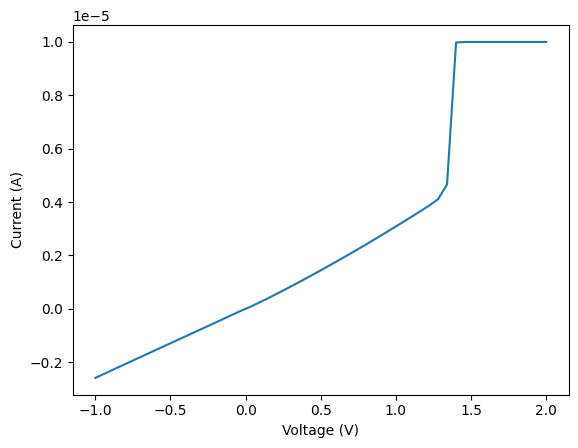

In [8]:
plt.plot(voltage, current)
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")